# Exploratory Data Analysis with Pyspark and Spark SQL

The following notebook utilizes New York City taxi data from [TLC Trip Record Data](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page)

## Instructions

- Load and explore nyc taxi data from january 0f 2019. The exercises can be executed using pyspark or spark sql ( a subset of the questions will be re-answered using the language not chosen for the  main work).
- Load the zone lookup table to answer the questions about the nyc boroughs.  
- Load nyc taxi data from January of 2025 and compare data.  
- With any remaining time, work on the where to go from here section.  
- Lab due date is TBD ( due dates will be updated in the readme for the class repo )

In [0]:
# Define the name of the new catalog
catalog = 'taxi_eda_db'

# define variables for the trips data
schema = 'yellow_taxi_trips'
volume = 'data'
file_name = 'yellow_tripdata_2019-01.parquet'
table_name = 'tbl_yellow_taxi_trips'
path_volume = '/Volumes/' + catalog + "/" + schema + '/' + volume
path_table =  catalog + "." + schema
download_url = 'https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2019-01.parquet'

In [0]:
# create the catalog/schema/volume
spark.sql('create catalog if not exists ' + catalog)
spark.sql('create schema if not exists ' + catalog + '.' + schema)
spark.sql('create volume if not exists ' + catalog + '.' + schema + '.' + volume)

DataFrame[]

In [0]:
# Get the data
dbutils.fs.cp(f"{download_url}", f"{path_volume}" + "/" + f"{file_name}")

True

In [0]:
# create the dataframe
df_trips = spark.read.parquet(f"{path_volume}/{file_name}",
  header=True,
  inferSchema=True,
  sep=",")

In [0]:
# Show the dataframe
df_trips.show()

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|airport_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|       1| 2019-01-01 00:46:40|  2019-01-01 00:53:20|            1.0|          1.5|       1.0|                 N|         151|         239|           1|        7.0|  0.5|    0.5|      1.6

In [0]:
df_trips.limit(10).toPandas()


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,1,2019-01-01 00:46:40,2019-01-01 00:53:20,1.0,1.5,1.0,N,151,239,1,7.0,0.5,0.5,1.65,0.00,0.3,9.95,NaN,NaN
1,1,2019-01-01 00:59:47,2019-01-01 01:18:59,1.0,2.6,1.0,N,239,246,1,14.0,0.5,0.5,1.00,0.00,0.3,16.30,NaN,NaN
2,2,2018-12-21 13:48:30,2018-12-21 13:52:40,3.0,0.0,1.0,N,236,236,1,4.5,0.5,0.5,0.00,0.00,0.3,5.80,NaN,NaN
3,2,2018-11-28 15:52:25,2018-11-28 15:55:45,5.0,0.0,1.0,N,193,193,2,3.5,0.5,0.5,0.00,0.00,0.3,7.55,NaN,NaN
4,2,2018-11-28 15:56:57,2018-11-28 15:58:33,5.0,0.0,2.0,N,193,193,2,52.0,0.0,0.5,0.00,0.00,0.3,55.55,NaN,NaN
5,2,2018-11-28 16:25:49,2018-11-28 16:28:26,5.0,0.0,1.0,N,193,193,2,3.5,0.5,0.5,0.00,5.76,0.3,13.31,NaN,NaN
6,2,2018-11-28 16:29:37,2018-11-28 16:33:43,5.0,0.0,2.0,N,193,193,2,52.0,0.0,0.5,0.00,0.00,0.3,55.55,NaN,NaN
7,1,2019-01-01 00:21:28,2019-01-01 00:28:37,1.0,1.3,1.0,N,163,229,1,6.5,0.5,0.5,1.25,0.00,0.3,9.05,NaN,NaN
8,1,2019-01-01 00:32:01,2019-01-01 00:45:39,1.0,3.7,1.0,N,229,7,1,13.5,0.5,0.5,3.70,0.00,0.3,18.50,NaN,NaN
9,1,2019-01-01 00:57:32,2019-01-01 01:09:32,2.0,2.1,1.0,N,141,234,1,10.0,0.5,0.5,1.70,0.00,0.3,13.00,NaN,NaN


## Lab

### Part 1
This section can be completed either using pyspark commands or sql commands ( There will be a section after in which a self-chosen subset of the questions are re-answered using the language not used for the main section. i.e. if pyspark is chosen for the main lab, sql should be used to repeat some of the questions. )

- Add a column that creates a unique key to identify each record in order to answer questions about individual trips
- Which trip has the highest passanger count
- What is the Average passanger count
- Shortest/longest trip by distance? by time?.
- busiest day/slowest single day
- busiest/slowest time of day ( you may want to bucket these by hour or create timess such as morning, afternoon, evening, late night )
- On average which day of the week is slowest/busiest
- Does trip distance or num passangers affect tip amount
- What was the highest "extra" charge and which trip
- Are there any datapoints that seem to be strange/outliers (make sure to explain your reasoning in a markdown cell)?

In [0]:
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number, lit

window = Window.orderBy(lit(1))
df_trips = df_trips.withColumn("trip_id", row_number().over(window))
df_trips.limit(10).toPandas()


/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1061: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,trip_id
0,1,2019-01-01 00:46:40,2019-01-01 00:53:20,1.0,1.5,1.0,N,151,239,1,7.0,0.5,0.5,1.65,0.00,0.3,9.95,NaN,NaN,1
1,1,2019-01-01 00:59:47,2019-01-01 01:18:59,1.0,2.6,1.0,N,239,246,1,14.0,0.5,0.5,1.00,0.00,0.3,16.30,NaN,NaN,2
2,2,2018-12-21 13:48:30,2018-12-21 13:52:40,3.0,0.0,1.0,N,236,236,1,4.5,0.5,0.5,0.00,0.00,0.3,5.80,NaN,NaN,3
3,2,2018-11-28 15:52:25,2018-11-28 15:55:45,5.0,0.0,1.0,N,193,193,2,3.5,0.5,0.5,0.00,0.00,0.3,7.55,NaN,NaN,4
4,2,2018-11-28 15:56:57,2018-11-28 15:58:33,5.0,0.0,2.0,N,193,193,2,52.0,0.0,0.5,0.00,0.00,0.3,55.55,NaN,NaN,5
5,2,2018-11-28 16:25:49,2018-11-28 16:28:26,5.0,0.0,1.0,N,193,193,2,3.5,0.5,0.5,0.00,5.76,0.3,13.31,NaN,NaN,6
6,2,2018-11-28 16:29:37,2018-11-28 16:33:43,5.0,0.0,2.0,N,193,193,2,52.0,0.0,0.5,0.00,0.00,0.3,55.55,NaN,NaN,7
7,1,2019-01-01 00:21:28,2019-01-01 00:28:37,1.0,1.3,1.0,N,163,229,1,6.5,0.5,0.5,1.25,0.00,0.3,9.05,NaN,NaN,8
8,1,2019-01-01 00:32:01,2019-01-01 00:45:39,1.0,3.7,1.0,N,229,7,1,13.5,0.5,0.5,3.70,0.00,0.3,18.50,NaN,NaN,9
9,1,2019-01-01 00:57:32,2019-01-01 01:09:32,2.0,2.1,1.0,N,141,234,1,10.0,0.5,0.5,1.70,0.00,0.3,13.00,NaN,NaN,10


/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1061: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


In [0]:
from pyspark.sql.functions import col

df_trips.orderBy(col("passenger_count").desc()).select("trip_id", "passenger_count").show(1)

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1061: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+-------+---------------+
|trip_id|passenger_count|
+-------+---------------+
| 949957|            9.0|
+-------+---------------+
only showing top 1 row


In [0]:
from pyspark.sql.functions import avg

df_trips.select(avg("passenger_count").alias("average_passenger_count")).show()


/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1061: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+-----------------------+
|average_passenger_count|
+-----------------------+
|     1.5670317144945614|
+-----------------------+



In [0]:
df_trips.orderBy(col("trip_distance").asc()).select("trip_id", "trip_distance").show(1)
df_trips.orderBy(col("trip_distance").desc()).select("trip_id", "trip_distance").show(1)


/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1061: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+-------+-------------+
|trip_id|trip_distance|
+-------+-------------+
|      3|          0.0|
+-------+-------------+
only showing top 1 row


/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1061: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+-------+-------------+
|trip_id|trip_distance|
+-------+-------------+
|6074092|        831.8|
+-------+-------------+
only showing top 1 row


In [0]:
from pyspark.sql.functions import expr, col

df_trips = df_trips.withColumn(
    "trip_duration_min",
    expr("timestampdiff(MINUTE, tpep_pickup_datetime, tpep_dropoff_datetime)")
)

df_trips.orderBy(col("trip_duration_min").asc()).select("trip_id", "trip_duration_min").show(1)
df_trips.orderBy(col("trip_duration_min").desc()).select("trip_id", "trip_duration_min").show(1)


/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1061: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+-------+-----------------+
|trip_id|trip_duration_min|
+-------+-----------------+
|1203185|           -84280|
+-------+-----------------+
only showing top 1 row


/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1061: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+-------+-----------------+
|trip_id|trip_duration_min|
+-------+-----------------+
|  68268|            43648|
+-------+-----------------+
only showing top 1 row


In [0]:
from pyspark.sql.functions import to_date, count

df_by_day = df_trips.groupBy(to_date("tpep_pickup_datetime").alias("pickup_date")) \
              .agg(count("*").alias("num_trips")) \
              .orderBy(col("num_trips").desc())


/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1061: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


In [0]:
df_by_day.orderBy(col("num_trips").asc()).select("pickup_date", "num_trips").show(1)
df_by_day.orderBy(col("num_trips").desc()).select("pickup_date", "num_trips").show(1)

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1061: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+-----------+---------+
|pickup_date|num_trips|
+-----------+---------+
| 2018-12-21|        1|
+-----------+---------+
only showing top 1 row
+-----------+---------+
|pickup_date|num_trips|
+-----------+---------+
| 2019-01-25|   292499|
+-----------+---------+
only showing top 1 row


In [0]:
from pyspark.sql.functions import hour

df_trips = df_trips.withColumn("pickup_hour", hour("tpep_pickup_datetime"))
df_by_hour = df_trips.groupBy("pickup_hour").agg(count("*").alias("num_trips")).orderBy("pickup_hour")
display(df_by_hour)


/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1061: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


pickup_hour,num_trips
0,207842
1,149254
2,109421
3,78086
4,61424
5,75533
6,178598
7,304858
8,373742
9,365935


In [0]:
from pyspark.sql.functions import date_format

df_trips = df_trips.withColumn("day_of_week", date_format("tpep_pickup_datetime", "E"))
df_by_day_of_week = df_trips.groupBy("day_of_week").agg(count("*").alias("num_trips")).orderBy(col("num_trips").desc())
display(df_by_day_of_week)


/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1061: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


day_of_week,num_trips
Thu,1357043
Wed,1265264
Tue,1209084
Fri,1087215
Sat,1009985
Mon,908121
Sun,859905


In [0]:
df_by_day_of_week.orderBy(col("num_trips").asc()).select("day_of_week", "num_trips").show(1)
df_by_day_of_week.orderBy(col("num_trips").desc()).select("day_of_week", "num_trips").show(1)

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1061: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+-----------+---------+
|day_of_week|num_trips|
+-----------+---------+
|        Sun|   859905|
+-----------+---------+
only showing top 1 row
+-----------+---------+
|day_of_week|num_trips|
+-----------+---------+
|        Thu|  1357043|
+-----------+---------+
only showing top 1 row


In [0]:
df_trips.groupBy("passenger_count").agg(avg("tip_amount").alias("avg_tip")).orderBy("passenger_count").show()


/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1061: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+---------------+--------------------+
|passenger_count|             avg_tip|
+---------------+--------------------+
|           NULL|0.061789899553571406|
|            0.0|  1.7869007761051638|
|            1.0|  1.8283524429075058|
|            2.0|  1.8339324029045228|
|            3.0|  1.7955889568213272|
|            4.0|  1.7027097823846875|
|            5.0|  1.8698681146978595|
|            6.0|  1.8568302035247934|
|            7.0|   6.542631578947368|
|            8.0|   6.480689655172414|
|            9.0|  3.1166666666666667|
+---------------+--------------------+



In [0]:
from pyspark.sql.functions import when

df_trips = df_trips.withColumn(
    "distance_bucket",
    when(col("trip_distance") < 1, "<1mi")
    .when(col("trip_distance") < 3, "1-3mi")
    .when(col("trip_distance") < 5, "3-5mi")
    .when(col("trip_distance") < 10, "5-10mi")
    .when(col("trip_distance") < 20, "10-20mi")
    .otherwise("20mi+")
)

df_trips.groupBy("distance_bucket").agg(avg("tip_amount").alias("avg_tip")).orderBy("distance_bucket").show()


/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1061: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+---------------+------------------+
|distance_bucket|           avg_tip|
+---------------+------------------+
|          1-3mi|1.4519057215266515|
|        10-20mi| 6.017457858280227|
|          20mi+| 7.807431992607323|
|          3-5mi|2.2670216900890403|
|         5-10mi|3.4699004511456972|
|           <1mi|0.9403610547768468|
+---------------+------------------+



In [0]:
df_trips.orderBy(col("extra").desc()).select("trip_id", "extra").show(1)

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1061: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+-------+------+
|trip_id| extra|
+-------+------+
|5323484|535.38|
+-------+------+
only showing top 1 row


In [0]:
# Trips with abnormally long distances
df_trips.filter(col("trip_distance") > 150).select("trip_id", "trip_distance").show()

# Trips with negative durations (likely data entry errors)
df_trips.filter(col("trip_duration_min") < 0).select("trip_id", "trip_duration_min").show()

# Trips with very high total amounts
df_trips.filter(col("total_amount") > 5000).select("trip_id", "total_amount").show()


/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1061: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+-------+-------------+
|trip_id|trip_distance|
+-------+-------------+
|4286634|        700.7|
|4707535|       211.36|
|4813336|       160.52|
|4881786|       201.27|
|6074092|        831.8|
|6770986|       214.01|
+-------+-------------+

+-------+-----------------+
|trip_id|trip_duration_min|
+-------+-----------------+
|1203185|           -84280|
|2976294|           -27817|
|4741747|            -2838|
|5175776|               -1|
+-------+-----------------+

+-------+------------+
|trip_id|total_amount|
+-------+------------+
| 233859|    18477.08|
| 233860|    17242.81|
| 301113|    25356.38|
| 478820|     6667.45|
| 651634|    31107.91|
| 737332|    30130.71|
|1368573|    19863.26|
|1368574|    19194.52|
|1419686|    25628.96|
|1649452|    33023.53|
|1892782|    34674.65|
|2159972|     36090.3|
|2444778|    30444.52|
|2499656|   623261.66|
|2841025|      8001.1|
|3154961|    20765.39|
|3154962|    16032.47|
|3208274|    16032.47|
|3208275|    24249.43|
|5323484|   356214.78|
+----

### Part 2

- Using the code for loading the first dataset as an example, load in the taxi zone lookup and answer the following questions
- which borough had most pickups? dropoffs?
- what are the busy/slow times by borough 
- what are the busiest days of the week by borough?
- what is the average trip distance by borough?
- what is the average trip fare by borough?
- highest/lowest faire amounts for a trip, what burough is associated with the each
- load the dataset from the most recently available january, is there a change to any of the average metrics.

In [0]:
# define variables for the trips data
schema = 'yellow_taxi_trips'
volume = 'data'
file_name = 'taxi_zones.parquet'
table_name = 'tbl_yellow_taxi_trips'
path_volume = '/Volumes/' + catalog + "/" + schema + '/' + volume
path_table =  catalog + "." + schema
download_url = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"


In [0]:
# create the catalog/schema/volume
spark.sql('create catalog if not exists ' + catalog)
spark.sql('create schema if not exists ' + catalog + '.' + schema)
spark.sql('create volume if not exists ' + catalog + '.' + schema + '.' + volume)

DataFrame[]

In [0]:
# Get the data
dbutils.fs.cp(f"{download_url}", f"{path_volume}" + "/" + f"{file_name}")

True

In [0]:
# create the dataframe
df_zone = spark.read.csv(f"{path_volume}/{file_name}",
  header=True,
  inferSchema=True,
  sep=",")

In [0]:
df_zone.show()

+----------+-------------+--------------------+------------+
|LocationID|      Borough|                Zone|service_zone|
+----------+-------------+--------------------+------------+
|         1|          EWR|      Newark Airport|         EWR|
|         2|       Queens|         Jamaica Bay|   Boro Zone|
|         3|        Bronx|Allerton/Pelham G...|   Boro Zone|
|         4|    Manhattan|       Alphabet City| Yellow Zone|
|         5|Staten Island|       Arden Heights|   Boro Zone|
|         6|Staten Island|Arrochar/Fort Wad...|   Boro Zone|
|         7|       Queens|             Astoria|   Boro Zone|
|         8|       Queens|        Astoria Park|   Boro Zone|
|         9|       Queens|          Auburndale|   Boro Zone|
|        10|       Queens|        Baisley Park|   Boro Zone|
|        11|     Brooklyn|          Bath Beach|   Boro Zone|
|        12|    Manhattan|        Battery Park| Yellow Zone|
|        13|    Manhattan|   Battery Park City| Yellow Zone|
|        14|     Brookly

In [0]:
from pyspark.sql.functions import col

df_joined = (
    df_trips
    .join(df_zone, df_trips.PULocationID == df_zone.LocationID, "left")
    .withColumnRenamed("Borough", "pickup_borough")
    .withColumnRenamed("Zone", "pickup_zone")

    .drop("LocationID", "service_zone")

    .join(df_zone, df_trips.DOLocationID == df_zone.LocationID, "left")
    .withColumnRenamed("Borough", "dropoff_borough")
    .withColumnRenamed("Zone", "dropoff_zone")
    
    .drop("LocationID", "service_zone")
)


/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1061: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


In [0]:
df_joined.limit(10).toPandas()

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1061: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,trip_id,trip_duration_min,pickup_hour,day_of_week,distance_bucket,pickup_borough,pickup_zone,dropoff_borough,dropoff_zone
0,2,2018-11-28 16:29:37,2018-11-28 16:33:43,5.0,0.0,2.0,N,193,193,2,52.0,0.0,0.5,0.00,0.00,0.3,55.55,NaN,NaN,7,4,16,Wed,<1mi,Queens,Queensbridge/Ravenswood,Queens,Queensbridge/Ravenswood
1,1,2019-01-01 00:57:32,2019-01-01 01:09:32,2.0,2.1,1.0,N,141,234,1,10.0,0.5,0.5,1.70,0.00,0.3,13.00,NaN,NaN,10,12,0,Tue,1-3mi,Manhattan,Lenox Hill West,Manhattan,Union Sq
2,1,2019-01-01 00:46:40,2019-01-01 00:53:20,1.0,1.5,1.0,N,151,239,1,7.0,0.5,0.5,1.65,0.00,0.3,9.95,NaN,NaN,1,6,0,Tue,1-3mi,Manhattan,Manhattan Valley,Manhattan,Upper West Side South
3,2,2018-12-21 13:48:30,2018-12-21 13:52:40,3.0,0.0,1.0,N,236,236,1,4.5,0.5,0.5,0.00,0.00,0.3,5.80,NaN,NaN,3,4,13,Fri,<1mi,Manhattan,Upper East Side North,Manhattan,Upper East Side North
4,1,2019-01-01 00:59:47,2019-01-01 01:18:59,1.0,2.6,1.0,N,239,246,1,14.0,0.5,0.5,1.00,0.00,0.3,16.30,NaN,NaN,2,19,0,Tue,1-3mi,Manhattan,Upper West Side South,Manhattan,West Chelsea/Hudson Yards
5,1,2019-01-01 00:32:01,2019-01-01 00:45:39,1.0,3.7,1.0,N,229,7,1,13.5,0.5,0.5,3.70,0.00,0.3,18.50,NaN,NaN,9,13,0,Tue,3-5mi,Manhattan,Sutton Place/Turtle Bay North,Queens,Astoria
6,1,2019-01-01 00:21:28,2019-01-01 00:28:37,1.0,1.3,1.0,N,163,229,1,6.5,0.5,0.5,1.25,0.00,0.3,9.05,NaN,NaN,8,7,0,Tue,1-3mi,Manhattan,Midtown North,Manhattan,Sutton Place/Turtle Bay North
7,2,2018-11-28 16:25:49,2018-11-28 16:28:26,5.0,0.0,1.0,N,193,193,2,3.5,0.5,0.5,0.00,5.76,0.3,13.31,NaN,NaN,6,2,16,Wed,<1mi,Queens,Queensbridge/Ravenswood,Queens,Queensbridge/Ravenswood
8,2,2018-11-28 15:56:57,2018-11-28 15:58:33,5.0,0.0,2.0,N,193,193,2,52.0,0.0,0.5,0.00,0.00,0.3,55.55,NaN,NaN,5,1,15,Wed,<1mi,Queens,Queensbridge/Ravenswood,Queens,Queensbridge/Ravenswood
9,2,2018-11-28 15:52:25,2018-11-28 15:55:45,5.0,0.0,1.0,N,193,193,2,3.5,0.5,0.5,0.00,0.00,0.3,7.55,NaN,NaN,4,3,15,Wed,<1mi,Queens,Queensbridge/Ravenswood,Queens,Queensbridge/Ravenswood


In [0]:
from pyspark.sql.functions import count

# Most pickups
df_pickups = df_joined.groupBy("pickup_borough").agg(count("*").alias("num_pickups"))
df_pickups.orderBy(col("num_pickups").desc()).show(1)

# Most dropoffs
df_dropoffs = df_joined.groupBy("dropoff_borough").agg(count("*").alias("num_dropoffs"))
df_dropoffs.orderBy(col("num_dropoffs").desc()).show(1)


/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1061: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+--------------+-----------+
|pickup_borough|num_pickups|
+--------------+-----------+
|     Manhattan|    6950965|
+--------------+-----------+
only showing top 1 row
+---------------+------------+
|dropoff_borough|num_dropoffs|
+---------------+------------+
|      Manhattan|     6817355|
+---------------+------------+
only showing top 1 row


In [0]:
from pyspark.sql.window import Window
from pyspark.sql.functions import col, max as spark_max, min as spark_min

# Define a window partitioned by borough
window_borough = Window.partitionBy("pickup_borough")

df_by_hour = (
    df_joined
    .withColumn("pickup_hour", hour("tpep_pickup_datetime"))
    .groupBy("pickup_borough", "pickup_hour")
    .agg(count("*").alias("num_trips"))
    .withColumn("max_trips", spark_max("num_trips").over(window_borough))
    .withColumn("min_trips", spark_min("num_trips").over(window_borough))
    .filter((col("num_trips") == col("max_trips")) | (col("num_trips") == col("min_trips")))
    .select("pickup_borough", "pickup_hour", "num_trips")
    .orderBy("pickup_borough")
)

display(df_by_hour)


/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1061: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


pickup_borough,pickup_hour,num_trips
Bronx,2,225
Bronx,7,1803
Bronx,3,225
Brooklyn,3,1919
Brooklyn,8,6935
EWR,23,1
EWR,1,1
EWR,15,54
Manhattan,4,53447
Manhattan,18,471539


In [0]:
from pyspark.sql.functions import date_format
from pyspark.sql.window import Window
from pyspark.sql.functions import col, max as spark_max, min as spark_min

df_by_day = (
    df_joined
    .withColumn("day_of_week", date_format("tpep_pickup_datetime", "E"))  # Mon, Tue, ...
    .groupBy("pickup_borough", "day_of_week")
    .agg(count("*").alias("num_trips"))
)


# Window partitioned by borough
window_borough = Window.partitionBy("pickup_borough")

df_by_day_status = (
    df_by_day
    .withColumn("max_trips", spark_max("num_trips").over(window_borough))
    .withColumn("min_trips", spark_min("num_trips").over(window_borough))
    .filter((col("num_trips") == col("max_trips")) | (col("num_trips") == col("min_trips")))
    .select("pickup_borough", "day_of_week", "num_trips")
    .orderBy("pickup_borough")
)

display(df_by_day_status)


/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1061: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


pickup_borough,day_of_week,num_trips
Bronx,Sat,1928
Bronx,Thu,3121
Brooklyn,Mon,9516
Brooklyn,Tue,15779
EWR,Wed,83
EWR,Mon,31
Manhattan,Thu,1229554
Manhattan,Sun,770225
N/A,Fri,443
N/A,Tue,703


In [0]:
from pyspark.sql.functions import avg

df_distance = df_joined.groupBy("pickup_borough").agg(avg("trip_distance").alias("avg_trip_distance"))
df_distance.orderBy(col("avg_trip_distance").desc()).show()


/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1061: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+--------------+------------------+
|pickup_borough| avg_trip_distance|
+--------------+------------------+
| Staten Island|12.503601108033246|
|        Queens|11.283218499361993|
|         Bronx| 7.233194552098303|
|      Brooklyn| 4.787677275447492|
|           N/A| 3.193850899742941|
|           EWR| 2.641098654708519|
|       Unknown| 2.415464130400774|
|     Manhattan|2.2286693358402596|
+--------------+------------------+



In [0]:
df_fare = df_joined.groupBy("pickup_borough").agg(avg("fare_amount").alias("avg_fare"))
df_fare.orderBy(col("avg_fare").desc()).show()


/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1061: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+--------------+------------------+
|pickup_borough|          avg_fare|
+--------------+------------------+
|           EWR| 76.24024663677126|
|           N/A|  59.5731593830335|
| Staten Island|45.289861495844896|
|        Queens| 35.14462651722029|
|         Bronx| 26.26890543682963|
|      Brooklyn|18.649132800172286|
|       Unknown|14.944423051653523|
|     Manhattan|10.792468572351568|
+--------------+------------------+



In [0]:
df_max_fare = df_joined.orderBy(col("fare_amount").desc()).select("trip_id", "fare_amount", "pickup_borough", "dropoff_borough").limit(1)
df_min_fare = df_joined.orderBy(col("fare_amount").asc()).select("trip_id", "fare_amount", "pickup_borough", "dropoff_borough").limit(1)

df_max_fare.show()
df_min_fare.show()


/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1061: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+-------+-----------+--------------+---------------+
|trip_id|fare_amount|pickup_borough|dropoff_borough|
+-------+-----------+--------------+---------------+
|2499656|  623259.86|     Manhattan|      Manhattan|
+-------+-----------+--------------+---------------+

+-------+-----------+--------------+---------------+
|trip_id|fare_amount|pickup_borough|dropoff_borough|
+-------+-----------+--------------+---------------+
|4890650|     -362.0|        Queens|         Queens|
+-------+-----------+--------------+---------------+



For january 2019:

| pickup_borough | avg_trip_distance |
|----------------|------------------|
| Staten Island  | 12.503601108033246 |
| Queens         | 11.283218499361993 |
| Bronx          | 7.233194552098303  |
| Brooklyn       | 4.787677275447492  |
| N/A            | 3.193850899742941  |
| EWR            | 2.641098654708519  |
| Unknown        | 2.415464130400774  |
| Manhattan      | 2.2286693358402596 |

| pickup_borough | avg_fare           |
|----------------|--------------------|
| EWR            | 76.24024663677126  |
| N/A            | 59.5731593830335   |
| Staten Island  | 45.289861495844896 |
| Queens         | 35.14462651722029  |
| Bronx          | 26.26890543682963  |
| Brooklyn       | 18.649132800172286 |
| Unknown        | 14.944423051653523 |
| Manhattan      | 10.792468572351568 |

for january 2025:

| pickup_borough | avg_trip_distance     |
|----------------|----------------------|
| Bronx          | 65.91340478936304    |
| N/A            | 28.235833333333336   |
| Brooklyn       | 24.807041925231157   |
| Queens         | 13.360874380478473   |
| Staten Island  | 8.305703124999999    |
| Manhattan      | 4.4439188903536015   |
| Unknown        | 3.202056258444915    |
| EWR            | 0.8962864721485414   |

| pickup_borough | avg_fare           |
|----------------|--------------------|
| EWR            | 81.47989389920424  |
| N/A            | 78.32668840579711  |
| Queens         | 48.35070962689943  |
| Bronx          | 27.772212197272925 |
| Staten Island  | 23.920820312500005 |
| Brooklyn       | 23.4369228091425   |
| Unknown        | 18.669125414568267 |
| Manhattan      | 13.869130184261868 |





### Part 3

- choose 3 questions from above and re-answer them using the language you did not use for the main notebook . (i.e - if you completed the exercise in python, redo 3 questions in pure sql) . at least one of the questions to be redone must involve a join

In [0]:
df_trips.createOrReplaceTempView("yellow_taxi_trips")
df_zone.createOrReplaceTempView("taxi_zones")


/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1061: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


In [0]:
%sql
-- Borough with most pickups
SELECT 
    z.Borough AS pickup_borough,
    COUNT(*) AS num_pickups
FROM yellow_taxi_trips t
JOIN taxi_zones z
    ON t.PULocationID = z.LocationID
GROUP BY z.Borough
ORDER BY num_pickups DESC
LIMIT 1;


pickup_borough,num_pickups
Manhattan,6950965


In [0]:
%sql
-- Average fare per pickup borough
SELECT 
    z.Borough AS pickup_borough,
    AVG(t.fare_amount) AS avg_fare
FROM yellow_taxi_trips t
JOIN taxi_zones z
    ON t.PULocationID = z.LocationID
GROUP BY z.Borough
ORDER BY avg_fare DESC;


pickup_borough,avg_fare
EWR,76.24024663677126
N/A,59.5731593830335
Staten Island,45.289861495844896
Queens,35.14462651722029
Bronx,26.26890543682963
Brooklyn,18.649132800172286
Unknown,14.944423051653523
Manhattan,10.792468572351568


In [0]:
%sql
-- Average trip distance per pickup borough
SELECT 
    z.Borough AS pickup_borough,
    AVG(t.trip_distance) AS avg_trip_distance
FROM yellow_taxi_trips t
JOIN taxi_zones z
    ON t.PULocationID = z.LocationID
GROUP BY z.Borough
ORDER BY avg_trip_distance DESC;


pickup_borough,avg_trip_distance
Staten Island,12.503601108033246
Queens,11.283218499361993
Bronx,7.233194552098303
Brooklyn,4.787677275447492
N/A,3.193850899742941
EWR,2.641098654708519
Unknown,2.415464130400774
Manhattan,2.2286693358402596



### Part 4

As of spark v4 dataframes have native visualization support. Choose at least 3 questions from above and provide visualizations.


/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1061: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(
/home/spark-ac9e6627-1d79-4545-b71f-2b/.ipykernel/2454/command-8624956554876260-2653664424:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_pickups_pd, x="pickup_borough", y="count", palette="viridis")


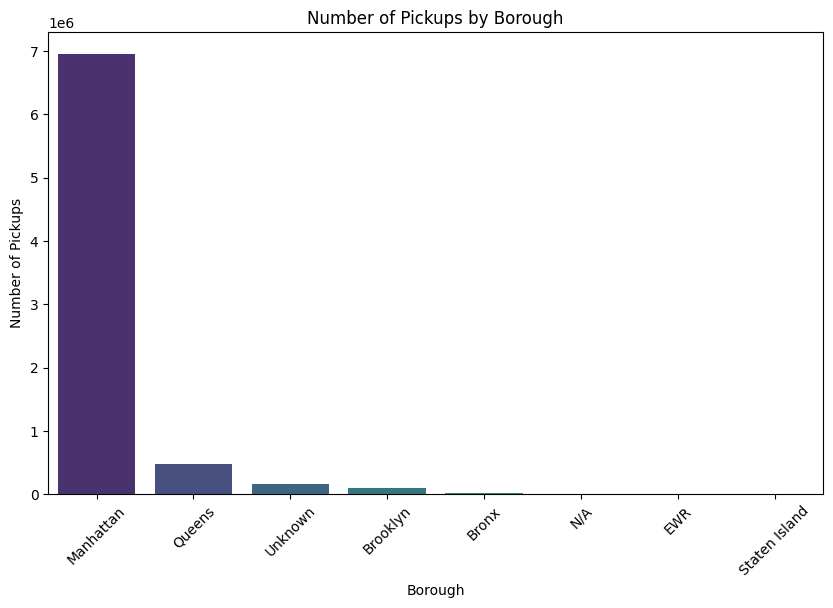

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert Spark DF to Pandas
df_pickups_pd = df_joined.groupBy("pickup_borough") \
                         .count() \
                         .orderBy("count", ascending=False) \
                         .toPandas()

# Plot
plt.figure(figsize=(10,6))
sns.barplot(data=df_pickups_pd, x="pickup_borough", y="count", palette="viridis")
plt.title("Number of Pickups by Borough")
plt.ylabel("Number of Pickups")
plt.xlabel("Borough")
plt.xticks(rotation=45)
plt.show()


/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1061: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(
/home/spark-ac9e6627-1d79-4545-b71f-2b/.ipykernel/2454/command-8624956554876261-1197607765:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_avg_fare_pd, x="pickup_borough", y="avg_fare", palette="coolwarm")


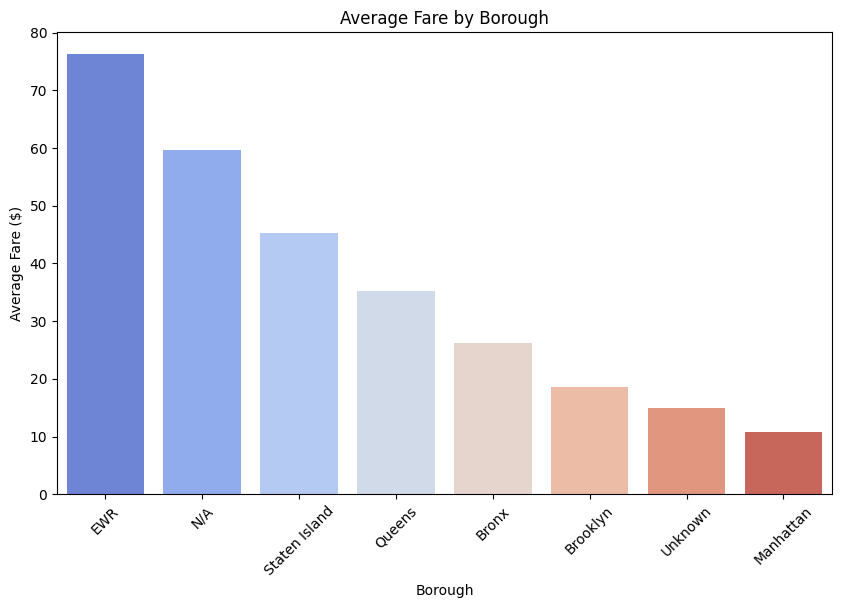

In [0]:
df_avg_fare_pd = df_joined.groupBy("pickup_borough") \
                           .agg(avg("fare_amount").alias("avg_fare")) \
                           .orderBy("avg_fare", ascending=False) \
                           .toPandas()

plt.figure(figsize=(10,6))
sns.barplot(data=df_avg_fare_pd, x="pickup_borough", y="avg_fare", palette="coolwarm")
plt.title("Average Fare by Borough")
plt.ylabel("Average Fare ($)")
plt.xlabel("Borough")
plt.xticks(rotation=45)
plt.show()


/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1061: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


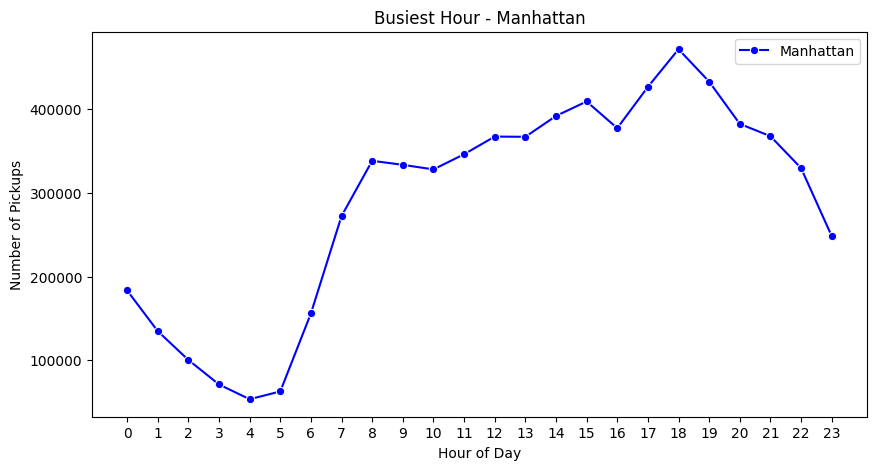

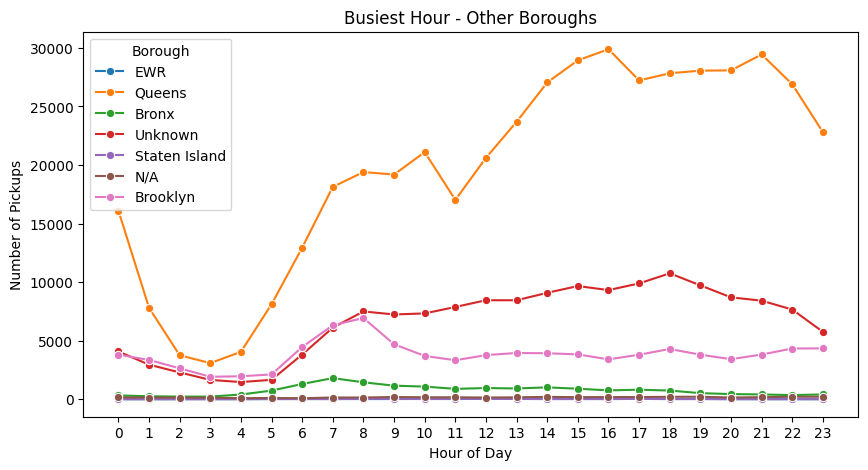

In [0]:
from pyspark.sql.functions import hour

df_by_hour = df_joined.withColumn("pickup_hour", hour("tpep_pickup_datetime")) \
                      .groupBy("pickup_borough", "pickup_hour") \
                      .count() \
                      .toPandas()

# Separate Manhattan and the others
df_manhattan = df_by_hour[df_by_hour['pickup_borough'] == 'Manhattan']
df_others = df_by_hour[df_by_hour['pickup_borough'] != 'Manhattan']

# --- Graph Manhattan ---
plt.figure(figsize=(10,5))
sns.lineplot(data=df_manhattan, x='pickup_hour', y='count', marker='o', label='Manhattan', color='blue')
plt.title("Busiest Hour - Manhattan")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Pickups")
plt.xticks(range(0,24))
plt.show()

# --- Graph Other Boroughs ---
plt.figure(figsize=(10,5))
sns.lineplot(data=df_others, x='pickup_hour', y='count', hue='pickup_borough', marker='o')
plt.title("Busiest Hour - Other Boroughs")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Pickups")
plt.xticks(range(0,24))
plt.legend(title="Borough")
plt.show()


# Where to go from here

- Continue building the dataset by loading in more data, start by completing the data for 2019 and calculating the busiest season (fall, winter, spring, summer)
- Explore a dataset/datasets of your choosing

In [0]:
# Define catalog/schema/volume once
catalog = 'taxi_eda_db'
schema = 'yellow_taxi_trips'
volume = 'data'
path_volume = f'/Volumes/{catalog}/{schema}/{volume}'

# Ensure catalog/schema/volume exist
spark.sql(f'CREATE CATALOG IF NOT EXISTS {catalog}')
spark.sql(f'CREATE SCHEMA IF NOT EXISTS {catalog}.{schema}')
spark.sql(f'CREATE VOLUME IF NOT EXISTS {catalog}.{schema}.{volume}')

# List of 12 months 2019
months = [
    "2019-01", "2019-02", "2019-03", "2019-04", "2019-05", "2019-06",
    "2019-07", "2019-08", "2019-09", "2019-10", "2019-11", "2019-12"
]

dfs = []

for m in months:
    file_name = f'yellow_tripdata_{m}.parquet'
    download_url = f'https://d37ci6vzurychx.cloudfront.net/trip-data/{file_name}'
    
    # Copy from URL to DBFS
    dbutils.fs.cp(download_url, f"{path_volume}/{file_name}")
    
    # Read Parquet into Spark DataFrame
    df_month = spark.read.parquet(f"{path_volume}/{file_name}")
    
    dfs.append(df_month)

# Union all months into a single DataFrame
df_trips_2019 = dfs[0]
for df_month in dfs[1:]:
    df_trips_2019 = df_trips_2019.union(df_month)

# Optional: create a temporary view for SQL queries
df_trips_2019.createOrReplaceTempView("yellow_trips_2019")

print(f"Loaded {len(months)} months into a single DataFrame.")


Loaded 12 months into a single DataFrame.


In [0]:
from pyspark.sql.functions import month

df_trips_2019 = df_trips_2019.withColumn("month", month("tpep_pickup_datetime"))

df_trips_2019 = df_trips_2019.withColumn(
    "season",
    when(df_trips_2019.month.isin([12,1,2]), "Winter")
    .when(df_trips_2019.month.isin([3,4,5]), "Spring")
    .when(df_trips_2019.month.isin([6,7,8]), "Summer")
    .otherwise("Fall")
)


In [0]:
df_season = df_trips_2019.groupBy("season").agg(count("*").alias("num_trips")) \
                         .orderBy("num_trips", ascending=False).limit(1)

display(df_season)


season,num_trips
Spring,22941027
